<a href="https://colab.research.google.com/github/SighanoCel/My-data-science-project/blob/main/Bank_transaction_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction

This notebook presents a comprehensive analysis of a fraud detection system, from initial data exploration to model deployment and interpretation. The primary objective is to develop a robust machine learning model capable of identifying fraudulent transactions while optimizing for business impact and operational efficiency.

#### Key Stages Covered:
- Data Loading and Initial Exploration: Importing and understanding the transactional dataset, including basic statistics and data quality checks.
- Exploratory Data Analysis (EDA): Deep diving into data distributions, relationships between features, and patterns related to fraudulent activities (e.g., transaction amounts, types, geographical concentrations, temporal trends).
- Feature Engineering: Preparing the data for modeling, including handling categorical variables and time-based features.
- Model Training (CatBoostClassifier): Developing a predictive model using CatBoost, a gradient boosting algorithm well-suited for tabular data and imbalanced classes which can process categorical features, common in fraud detection.
- Model Evaluation and Threshold Optimization: Assessing model performance using metrics like precision, recall, and false positive rate. A critical focus is placed on selecting an optimal classification threshold to balance fraud detection accuracy with operational costs.
- Model Interpretability (SHAP): Using SHAP values to explain the model's predictions, identifying the most influential features, and understanding their impact on fraud classification.
- Cost-Benefit Analysis & Actionable Recommendations: Translating model performance into financial terms to quantify the Return on Investment (ROI) and provide strategic recommendations for fraud prevention and resource allocation.

The insights derived throughout this notebook aim to inform data-driven decision-making, enhance fraud detection capabilities, and ultimately minimize financial losses for the organization.

In [ ]:
# importing python liabraries to clean, analyze and visualize data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.metrics import recall_score,precision_score,classification_report,confusion_matrix
from sklearn.metrics import precision_recall_curve
from scipy.stats import chi2_contingency
!pip install catboost
from catboost import CatBoostClassifier
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


In [ ]:
# let us import the CSV Dataset

df = pd.read_csv('/content/drive/MyDrive/Keaggle datasets project/Classification/Fraud.csv')
df.head(8)

,Date,nameOrig,amount,oldbalanceOrg,newbalanceOrig,City,type,Card Type,Exp Type,Gender,isFraud
0,26-May-13,C2011200430,242.0,302.00,60.00,"Ahmedabad, India",TRANSFER,Gold,Food,F,1
1,26-Jul-12,C931301500,7081.0,46066.00,38985.00,"Delhi, India",TRANSFER,Gold,Entertainment,M,1
2,12-Apr-12,C963642457,16355.0,30355.00,14000.00,"Kolkata, India",TRANSFER,Silver,Fuel,F,1
3,28-Jan-12,C1439438217,20820.0,39663.00,18843.00,"Lucknow, India",TRANSFER,Gold,Food,F,1
4,16-Apr-14,C892940485,6071.0,35586.00,29515.00,"Bengaluru, India",TRANSFER,Gold,Fuel,M,1
5,29-May-14,C1083550296,13450.0,46831.00,33381.00,"Bengaluru, India",TRANSFER,Silver,Bills,F,1
6,22-May-13,C117029699,37595.0,40189.00,2594.00,"Bengaluru, India",TRANSFER,Signature,Food,F,1
7,05-Mar-12,C215820497,102705.0,105078.57,2373.57,"Chennai, India",TRANSFER,Platinum,Entertainment,M,1


In [ ]:

# this line of code helps to read the dataset glossary
# to understand the meaning of the features.


with open('/content/drive/MyDrive/Keaggle datasets project/Classification/Fraud Detection Glossary.txt','r') as f:

  print(f.read())

1-Date: Date of Transaction 
2-nameOrig: User Name or Account number 
3-amount: Money in this transaction 
4-oldbalanceOrg: How much the client had money before transaction 
5-newbalanceOrig: How much the client have after the transaction 
6-City: where the transaction happened which city 
7-type: Type of transaction TRANSFER \ CASH_OUT, CASH_IN ,DEBIT,PAYMENT 
8-Card Type: The card type the client has \ Platinum ,Gold ,Silver ,Signature ,Classic ,Mass 
9-Exp Type:The purpose for transaction \ Food, Entertainment, Fuel, Bills, Grocery, Travel, Personal_Care, Health_Fitness, Home
10-Gender: Male or Female 
11- isFraud : 0 = no fraud \ 1= fraud


In [ ]:
# This line of code prints a concise summary of our dataframe
# It's excellent for quickly understanding the structure of our data
# and identifying missing values or incorrect data types.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Date            1048574 non-null  object 
 1   nameOrig        1048574 non-null  object 
 2   amount          1048574 non-null  float64
 3   oldbalanceOrg   1048574 non-null  float64
 4   newbalanceOrig  1048574 non-null  float64
 5   City            1048574 non-null  object 
 6   type            1048574 non-null  object 
 7   Card Type       1048574 non-null  object 
 8   Exp Type        1048574 non-null  object 
 9   Gender          1048574 non-null  object 
 10  isFraud         1048574 non-null  int64  
dtypes: float64(3), int64(1), object(7)
memory usage: 88.0+ MB


In [ ]:
# let's check if there are missing and/or duplicated values within the dataset.
# we notice that the dataset is complete. may be it has been cleaned before.


print(df[df.isnull()].sum())

print(df[df.duplicated()].sum())

Date                0
nameOrig            0
amount            0.0
oldbalanceOrg     0.0
newbalanceOrig    0.0
City                0
type                0
Card Type           0
Exp Type            0
Gender              0
isFraud           0.0
dtype: object
Date                0
nameOrig            0
amount            0.0
oldbalanceOrg     0.0
newbalanceOrig    0.0
City                0
type                0
Card Type           0
Exp Type            0
Gender              0
isFraud             0
dtype: object


In [4]:
# before performing the EDA and the ML
# we will remove the column 'nameOrig' as it might not be relevant
# or useful for the fraud detection model.

df = df.drop(['nameOrig'],axis=1)

df.head(6)

,Date,amount,oldbalanceOrg,newbalanceOrig,City,type,Card Type,Exp Type,Gender,isFraud
0,26-May-13,242.0,302.0,60.0,"Ahmedabad, India",TRANSFER,Gold,Food,F,1
1,26-Jul-12,7081.0,46066.0,38985.0,"Delhi, India",TRANSFER,Gold,Entertainment,M,1
2,12-Apr-12,16355.0,30355.0,14000.0,"Kolkata, India",TRANSFER,Silver,Fuel,F,1
3,28-Jan-12,20820.0,39663.0,18843.0,"Lucknow, India",TRANSFER,Gold,Food,F,1
4,16-Apr-14,6071.0,35586.0,29515.0,"Bengaluru, India",TRANSFER,Gold,Fuel,M,1
5,29-May-14,13450.0,46831.0,33381.0,"Bengaluru, India",TRANSFER,Silver,Bills,F,1


In [ ]:
# Here we calculate the Pearson correlation coefficient between all the numeric features
# in the dataframe and the 'isFraud' column which will represent the target.
# This code usually helps to detect a potential data leakage that could definately lead to overfitting.
# the data leakage occurs when an independent feature is strongly correlated to the target which can
# simply cause a biased and non performant model.
# We will calculate it a second time for the categorical feature.

correlation = df.corr(numeric_only=True)['isFraud'].sort_values(ascending=False)

correlation*100

,isFraud
isFraud,100.000000
amount,-4.973138
newbalanceOrig,-11.936387
oldbalanceOrg,-11.986429


In [12]:
# This algorithm perform a Chi-squared test of independence,
# a statistical algorithm to determine if there's a significant
# association between two categorical variables.Here we test the relationship between
# each of our categorical feature and the target as it isn't possible to
# compute a pearson, Kendall or Spearman correlation on non numeric values.

# We group all the categorical features in a list and assign it to "categoric_features"
categoric_features =['City','type','Card Type','Exp Type','Gender']



# next, we create a loop to iterate the algorithm for each categorical feature.
# then we construct a crosstab (contingency_table) which is a matrix that will
# display the frequency distribution of the variables. It essentially counts how many transactions
# fall into each combination of categories. eg. Gender Vs IsFraud we would have the following matrix

                         # is not Fraud(0)                                          is Fraud (1)

# Gender F  	Count of Non-Fraudulent for Female Transactions     	     Count of Fraudulent for Female Transactions
# Gender M	  Count of Non-Fraudulent for Male Transactions	             Count of Fraudulent for Male Transactions

for feature in categoric_features:

  contingency_table = pd.crosstab(df[feature], df["isFraud"])


# Here we calculate the expected frequencies which is the core of the Chi-squared test.
# it consists in comparing the observed frequencies(form our contingency_table) and the expected frequencies
# which are the frequencies we would anticipate if the 2 variable were perfectly independents)
# the formula of the expected prefequencies is row_total * column_total /grand Total
# Then we compute the chi squared test statistics(chi2_contingency) that  measures the discrepancy between
# the observed and expected frequencies across all cells in the table.
# Its formula is: chi² = Σ [ (Observed - Expected)² / Expected ]
# We end calculating P-Value of each feature (probability of observation of the discrepancies if there wasn't relationship between the 2 variables).
# For each feature, if the the P-value is > 0.05, we assume that there is
# no significant relationship with the target (isFraud), in the opossite case,
# there is statistical signifant association.


  chi2,p,dof,expected = chi2_contingency(contingency_table)

  print(f'- relationship between {feature.upper()} and isFraud = {p:.2%} :')


  if p > 0.05/100:

    print(f'_ There is no association with the target \n')
  else:

    print(f' *There is a significant association with the target \n')


- relationship between CITY and isFraud = 0.09% :
_ There is no association with the target 

- relationship between TYPE and isFraud = 0.00% :
 *There is a significant association with the target 

- relationship between CARD TYPE and isFraud = 12.99% :
_ There is no association with the target 

- relationship between EXP TYPE and isFraud = 0.09% :
_ There is no association with the target 

- relationship between GENDER and isFraud = 59.24% :
_ There is no association with the target 



In [13]:
contingency_table

isFraud,0,1
Gender,,
F,458678,92504
M,414111,83281


Based on the Chi-squared contingency test results above

The feature associated with the target 'isFraud' is type (the transaction type). Its p-value is 0.00%, which is significantly lower than the typical threshold for statistical significance (0.05). This indicates a very strong and statistically significant association between the type of transaction and whether it is fraudulent.
Here we have to highlight that strong association between this kine of feature and the target variable is generally a good thing for a predictive model. It means that the type of transaction is highly informative and provides valuable signal for distinguishing between fraudulent and non-fraudulent transactions. The model can leverage this strong relationship to make more accurate predictions. This is not considered 'data leakage' because the transaction type is a characteristic of the transaction itself and would be known at the time we need to predict if that transaction is fraudulent. Data leakage occurs when the model uses information that would not be available in a real-world prediction scenario.

In [ ]:
# Let us give a breakdown to the output of this code.
# The average transaction amount for fraudulent transactions
# is approximately 25780.88, which is lower than the average
# amount for non-fraudulent transactions, approximately 40494.25.
# The same occurs with the balance of the account before the transaction
# and the balance after the transaction which are lower in the fraudulent case
# and higher in the safe transaction.
# It means that fraudulent transactions, on average, involve a lower amount
# and occur with significantly lower oldbalanceOrig and newbalanceOrig compared to legitimate transactions.
# This could be a key differentiator when trying to identify fraudulent activity.


df.groupby('isFraud').mean(numeric_only= True)

,amount,oldbalanceOrg,newbalanceOrig
isFraud,,,
0,40494.249788,1.039962e+06,999467.545567
1,25780.876167,8.695750e+04,61176.621065


## 1- *Visualizing Average transaction amount,the old balance and the new balance for Fraudulent vs. Non-Fraudulent Transactions*

The following plots provide a clear comparison of three key numerical features (transaction amount, acount balance before the transaction, and account balance after the transaction) across fraudulent and non-fraudulent transactions. Each bar plot displays the average value of one of these features, segmented by the 'isFraud' status (0 for non-fraudulent, 1 for fraudulent).

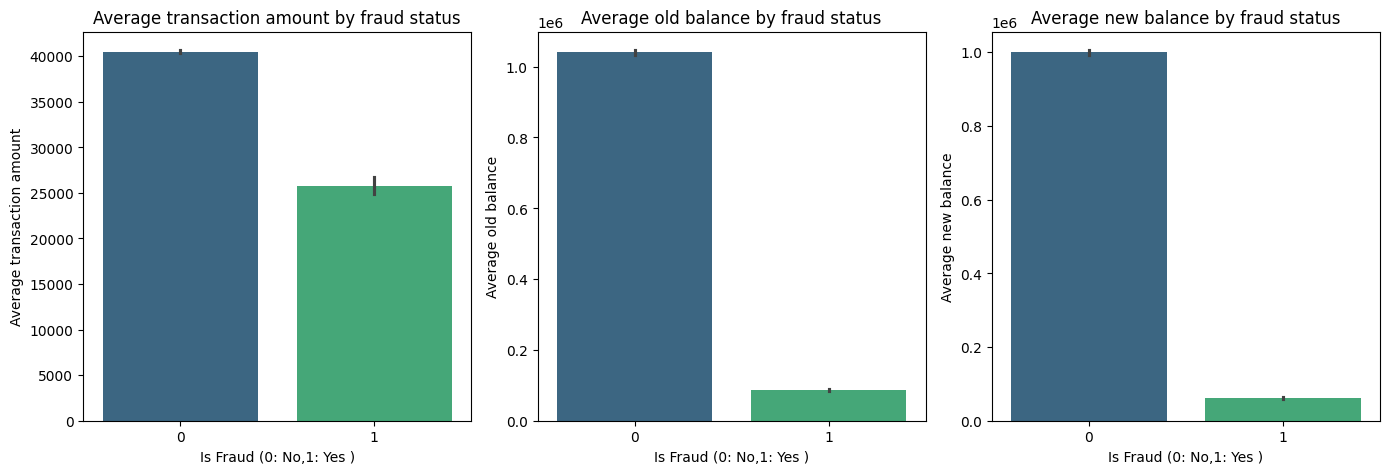

In [ ]:

renamed_df = df.rename(columns={'amount':'transaction amount','oldbalanceOrg':'old balance' ,'newbalanceOrig':'new balance'})

num_cols = renamed_df[['transaction amount','old balance','new balance']]

fig,ax = plt.subplots(1,3, figsize=(14,5))

for i, col in enumerate(num_cols):
  sns.barplot(data=renamed_df, x='isFraud', y=col, ax=ax[i], palette='viridis', hue='isFraud', legend=False)
  ax[i].set_title(f'Average {col} by fraud status')
  ax[i].set_xlabel('Is Fraud (0: No,1: Yes )')
  ax[i].set_ylabel (f'Average {col}');

plt.tight_layout()






#### **As insights from these plots, we can notice that**

- For the first plot,on average, fraudulent transactions tend to involve a significantly lower amount compared to legitimate transactions. This visual trend reinforces our earlier numerical analysis where the average fraudulent transaction amount was lower than non-fraudulent ones.

- The second plot shows that the average 'old balance' (the balance before the transaction) for fraudulent cases is considerably lower than for non-fraudulent ones. This suggests that fraudulent activities might often occur in accounts with smaller initial balances.

- The third plot, concerning the 'new balance' (the balance after the transaction), follows a similar pattern. Fraudulent transactions are associated with much lower average new balances than legitimate transactions.

These visual patterns are crucial for fraud detection as they underscore that fraudulent transactions, on average, involve smaller sums and affect accounts with lower balances compared to legitimate transactions. This differentiation can be a strong indicator that could help our model in predicting future transaction status.

## *2- Performing a comparative analysis between the overall frequency of transaction types and their impact on Fraud status.*

The first plot clearly shows that fraudulent transactions (isFraud = 1) are almost exclusively concentrated in two transaction types: TRANSFER and CASH_OUT. There are very few, if any, fraudulent instances detected in CASH_IN, DEBIT, or PAYMENT.
Within the fraudulent transactions, CASH_OUT and TRANSFER types show the most significant bars for isFraud = 1.
The bars for isFraud = 0 are present across all transaction types, indicating that all types are common in legitimate transactions.

The second plot reveals the overall distribution of transaction types in the dataset. CASH_OUT and PAYMENT are the most frequent transaction types, followed by CASH_IN and TRANSFER.
DEBIT transactions appear to be the least frequent.

Despite CASH_IN and PAYMENT being very frequent overall, they show almost no fraudulent activity. This highlights TRANSFER and CASH_OUT as the primary types to focus on for fraud detection, as actually all fraud occurs within these categories.
These insights suggest that models or rules designed to detect fraud should heavily weigh TRANSFER and CASH_OUT transactions, as they represent the highest risk categories. Investigating especially DEBIT and PAYMENT for fraud might yield very few true positives.

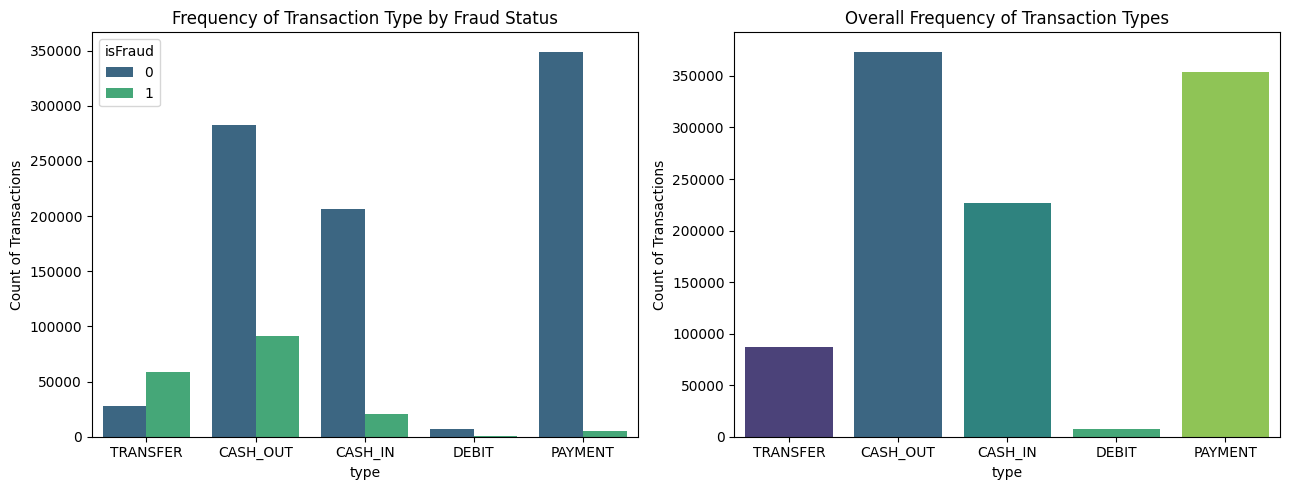

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(13,5))

sns.countplot(data=df, x='type',hue='isFraud',ax=axes[0], palette='viridis')
axes[0].set_title('Frequency of Transaction Type by Fraud Status')
axes[0].set_ylabel('Count of Transactions')

sns.countplot(data=df, x='type',hue='type',ax=axes[1],palette='viridis', legend=False)
axes[1].set_title('Overall Frequency of Transaction Types')
axes[1].set_ylabel('Count of Transactions')

plt.tight_layout()
plt.show()

## *3- Performing a comparative analysis between the overall frequency of Expense types and their relationship with Fraud status.*



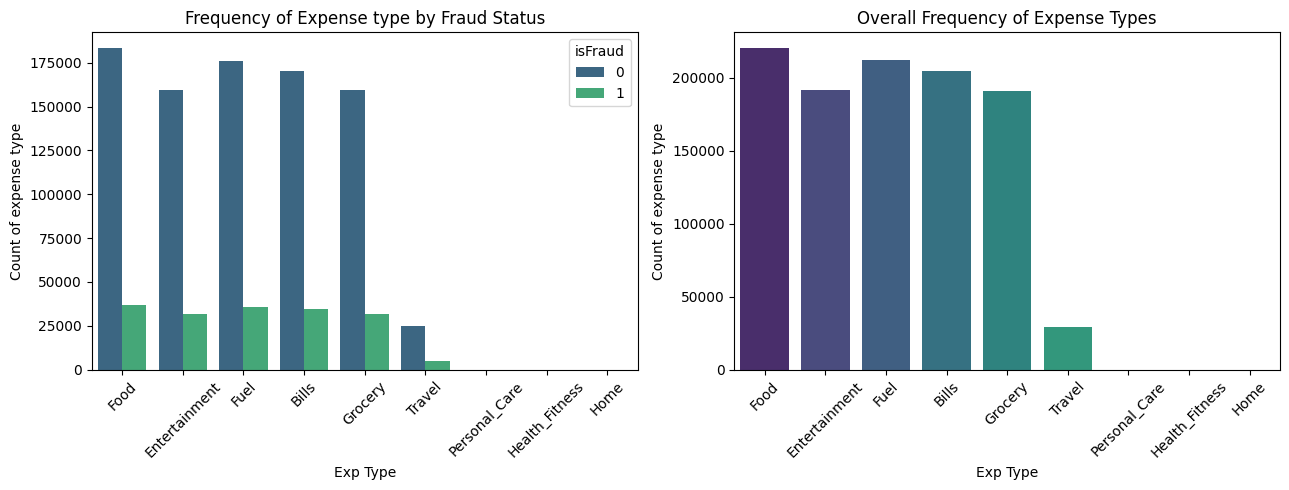

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(13,5))

sns.countplot(data=df, x='Exp Type',hue='isFraud',ax=axes[0], palette='viridis')
axes[0].set_title('Frequency of Expense type by Fraud Status')


sns.countplot(data=df, x='Exp Type',hue='Exp Type',ax=axes[1],palette='viridis', legend=False)
axes[1].set_title('Overall Frequency of Expense Types')


for n_row in range(1):
  for n_col in range(2):
    axes[n_col].tick_params(axis='x',rotation=45)
    axes[n_col].set_ylabel('Count of expense type')

plt.tight_layout()
plt.show()

#### **Interpretation of the frequency plot**

The plots suggest that the absolute number of fraudulent transactions for a given 'Exp Type' is largely proportional to its overall frequency of use. In other words, expense types that are used more often (like 'Food' or 'Fuel') naturally have a higher count of both legitimate and fraudulent transactions simply because there are more transactions overall in those categories.

This implies there isn't a specific 'Exp Type' that is inherently more susceptible to fraud at a disproportionately higher rate than others. If there were, we would see a significantly larger proportion of the fraudulent (purple) bars relative to the total transaction count for that specific expense type, even if its overall frequency was low. Instead, the ratio between fraudulent and non-fraudulent transactions seems relatively consistent across expense types, scaling with their overall volume.

So, the conclusion that when we are talking about expense type, the only risk lies in the frequency of use.

## *4- Analysis of Fraudulent Transactions Concentration by City*

This section delves into understanding how fraudulent transactions are distributed across different cities. By analyzing the concentration of fraud, we aim to identify whether a small percentage of cities accounts for a disproportionately large share of fraudulent activities, a phenomenon often described by the Pareto Principle (80/20 rule). This analysis helps in pinpointing high-risk geographical areas, which can be crucial for targeted fraud detection and prevention strategies. We will calculate cumulative percentages of both fraudulent transactions and cities to illustrate this concentration.

In [25]:
# for each city we calculate the total number of transactiona and the number fraudulent of fraudulent transaction .

city_stats = df.groupby('City').agg(total_transactions = ('isFraud','count'),
                                    total_frauds=('isFraud','sum'))


# We sort cities by the number of fraudulent transactions in descending order,
# setting the city index as a normal column
cumulative_frauds= city_stats.sort_values('total_frauds', ascending=False).reset_index()

# calculating the  cumulative percentages of both fraudulent transactions and cities.
cumulative_frauds['cumulative_frauds'] = cumulative_frauds['total_frauds'].cumsum()
cumulative_frauds['cumulative_frauds_percentage'] = (cumulative_frauds['cumulative_frauds'] / cumulative_frauds['total_frauds'].sum()) * 100
cumulative_frauds['cumulative_cities_percentage'] = (cumulative_frauds.index + 1) / len(cumulative_frauds) * 100

# then we use these cumulative percentages to identify and show how a high percentage of frauds
# concentrated are in a small percentage of cities,alligning to the 80/20 rule (Pareto principle).

top_80_fraud_percent= cumulative_frauds[cumulative_frauds['cumulative_frauds_percentage']>=80].index[0]

top_80_cities_percent= cumulative_frauds.loc[top_80_fraud_percent]['cumulative_cities_percentage']


# here we compute the same calculation from the cumlatives percentage, showing how a small percentage
# of cities experiences a high percentage over the total fraudulent transactions alliging with Pareto Principle

top_20_cities_percent = cumulative_frauds[cumulative_frauds['cumulative_cities_percentage']>=20].index[0]

top_20_fraud_percent = cumulative_frauds.loc[top_20_cities_percent]['cumulative_frauds_percentage']


print('=='*60)
print('\n' + f'The 80% of the total fraudulent transcations is mostly \
concentrated on almost {top_80_cities_percent:.2f}% of Cities')


print('=='*60)
print('\n' + f' And the 20% of cities experience appproximatively {top_20_fraud_percent:.2f}% \
over the total fraudulent transcations that we observe')

print('=='*60)



The 80% of the total fraudulent transcations is mostly concentrated on almost 7.10% of Cities

 And the 20% of cities experience appproximatively 84.72% over the total fraudulent transcations that we observe


In [26]:
cumulative_frauds[cumulative_frauds['cumulative_frauds_percentage']>=80]

,City,total_transactions,total_frauds,cumulative_frauds,cumulative_frauds_percentage,cumulative_cities_percentage
69,"Jalandhar, India",360,74,140670,80.023893,7.099391
70,"Bhuj, India",440,73,140743,80.065421,7.200811
71,"Kodungallur, India",320,73,140816,80.106949,7.302231
72,"Narsinghgarh, India",480,73,140889,80.148477,7.403651
73,"Sidhpur, India",400,73,140962,80.190005,7.505071
...,...,...,...,...,...,...
981,"Changanassery, India",40,6,175765,99.988622,99.594320
982,"Bagaha, India",40,6,175771,99.992036,99.695740
983,"Fazilka, India",40,6,175777,99.995449,99.797160
984,"Tirur, India",40,5,175782,99.998293,99.898580


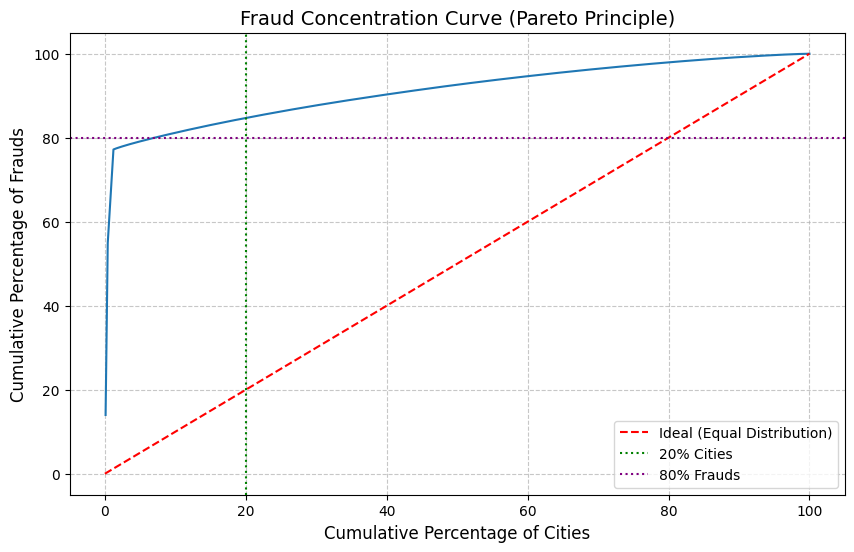

In [30]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='cumulative_cities_percentage', y='cumulative_frauds_percentage', data=cumulative_frauds)
plt.plot([0, 100],[0,100],color='red', linestyle='--', label='Ideal (Equal Distribution)') # Add ideal line

# Add 80/20 rule lines
plt.axvline(x=20, color='green', linestyle=':', label='20% Cities')
plt.axhline(y=80, color='purple', linestyle=':', label='80% Frauds')

plt.title('Fraud Concentration Curve (Pareto Principle)', fontsize=14)
plt.xlabel('Cumulative Percentage of Cities', fontsize=12)
plt.ylabel('Cumulative Percentage of Frauds', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

#### **Interpretation of the Fraud concentration curve**

- Steep Initial Rise: A steep incline at the beginning of the blue curve indicates that just a few cities are responsible for a significant chunk of the total fraudulent activity. This means that fraud is highly concentrated in specific locations.
- Gradual Flattening: As the curve progresses and more cities (those with fewer frauds) are added, the slope becomes less steep, eventually flattening. This reflects that the remaining large percentage of cities contribute only a small fraction to the overall fraud.

By observing how much the blue curve deviates from the red ideal line, and especially by examining the intersection points with the 80/20 rule lines, we can determine the extent to which fraud is concentrated. If, for instance, the curve shows that approximately 7% of cities account for about 80% of the total frauds (as observed in our earlier numerical analysis), it strongly supports the application of the Pareto principle. This insight is incredibly valuable for developing targeted strategies, allowing us to allocate resources more efficiently to the cities where they can have the greatest impact on mitigating fraud.
So far, the question to ask is what are those area where we observe the high percentage of fraudulent transaction?

## *5- Analyzing Fraudulent Transactions vs. Total Transactions by City*

This section provides a comparative analysis of cities based on two critical metrics: the total number of fraudulent transactions and the overall number of transactions. By examining these two aspects side-by-side, we aim to:

- Identify High-Fraud Cities: Pinpoint which cities experience the highest absolute numbers of fraudulent activities.
- Understand Relative Risk: Determine if cities with a high volume of total transactions also disproportionately contribute to fraud, or if fraud is concentrated in cities with lower overall transaction counts.
- Inform Targeted Strategies: Highlight specific urban areas where increased monitoring, security enhancements, or investigative resources might be most effectively deployed.



In [ ]:

overall_total_fraud = city_stats['total_frauds'].sum()
city_stats['fraud_percentage'] = (city_stats['total_frauds'] / overall_total_fraud* 100).round(2)

# Sort by fraudulent transaction
city_stats_sorted = city_stats.sort_values('total_frauds', ascending=False)

print("="*100)
print("top 10 cities with high fraudulent transactions")
print("="*100)
print(city_stats_sorted.head(10).to_string())

# Save top sections
top_10_cities = city_stats_sorted.head(10)


top 10 cities with high fraudulent transactions
                       total_transactions  total_frauds  fraud_percentage
City                                                                     
Bengaluru, India                   143733         24588             13.99
Greater Mumbai, India              141376         24033             13.67
Ahmedabad, India                   141231         23962             13.63
Delhi, India                       140874         23923             13.61
Hyderabad, India                    31360          4988              2.84
Kolkata, India                      30920          4961              2.82
Chennai, India                      30960          4943              2.81
Kanpur, India                       30560          4922              2.80
Lucknow, India                      30360          4905              2.79
Surat, India                        29960          4848              2.76


The two bar plots below illustrate the top 10 cities for each of these metrics, providing a clear visual overview of fraud and transaction distribution across the most active urban centers.

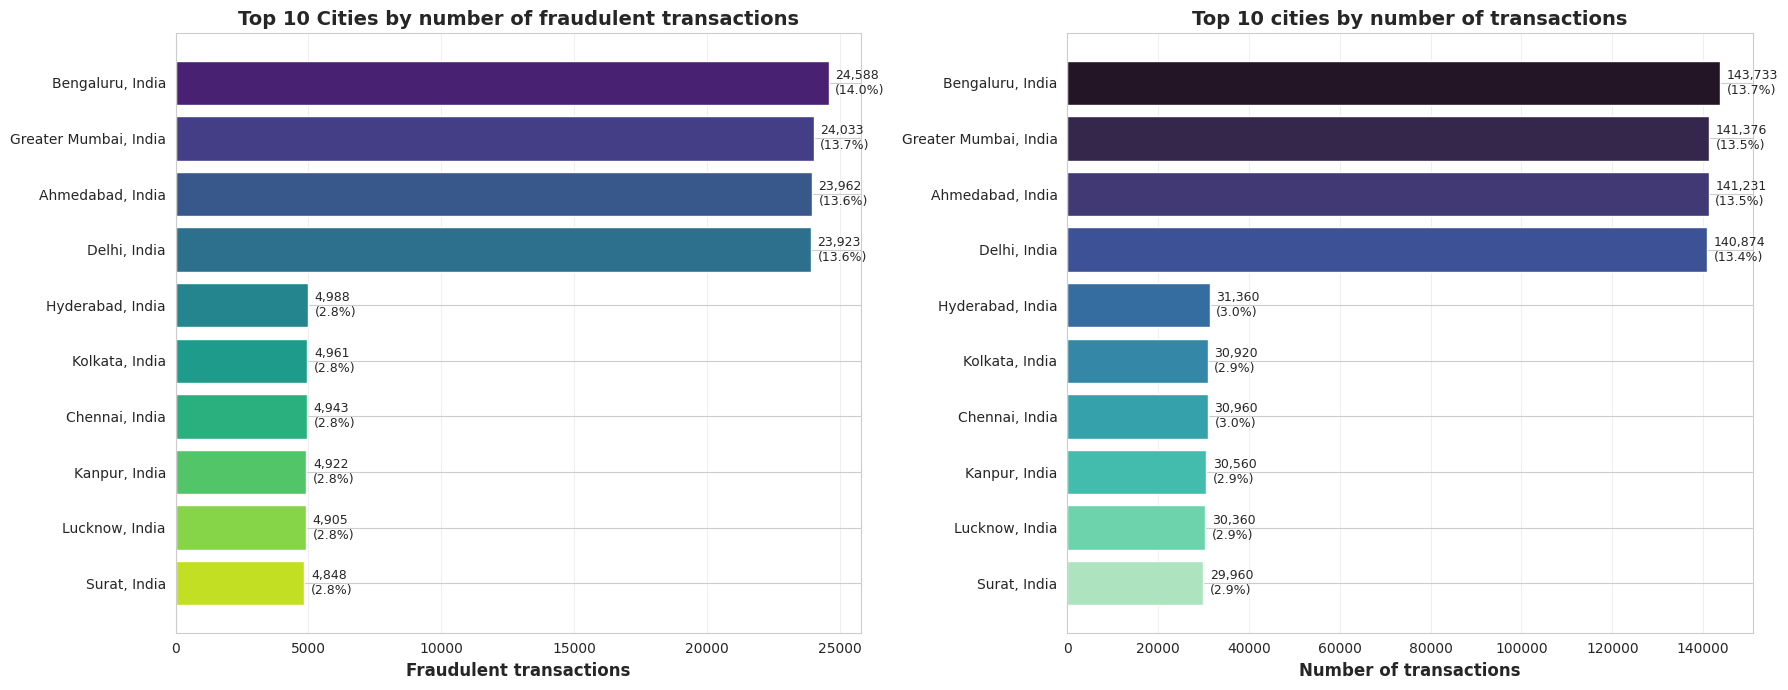

In [ ]:
sns.set_style("whitegrid")

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Fraudulents transaction by City (top 10 cities)
colors = sns.color_palette("viridis", 10)
ax1.barh(range(10), top_10_cities['total_frauds'], color=colors)
ax1.set_yticks(range(10))
ax1.set_yticklabels(top_10_cities.index, fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Fraudulent transactions', fontsize=12, fontweight='bold')
ax1.set_title('Top 10 Cities by number of fraudulent transactions', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_10_cities['total_frauds']):
    ax1.text(v + (top_10_cities['total_frauds'].max() * 0.01), i,
             f'{v:,.0f}\n({top_10_cities.iloc[i]["fraud_percentage"]:.1f}%)',
             va='center', fontsize=9)

# Plot 2: number of transaction by cities(top 10 cities)
colors_clients = sns.color_palette("mako", 10)
ax2.barh(range(10),top_10_cities['total_transactions'], color=colors_clients)
ax2.set_yticks(range(10))
ax2.set_yticklabels(top_10_cities.index, fontsize=10)
ax2.invert_yaxis()
ax2.set_xlabel('Number of transactions', fontsize=12, fontweight='bold')
ax2.set_title('Top 10 cities by number of transactions', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_10_cities['total_transactions']):
    transaction_percentage = (v /df.shape[0]* 100)
    ax2.text(v + (top_10_cities['total_transactions'].max() * 0.01), i,
             f'{int(v):,}\n({transaction_percentage:.1f}%)',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()


#### **Key Observations about the above charts**

- High Overlap in Top Cities: The most striking observation is the significant overlap between cities with the highest number of fraudulent transactions and those with the highest overall transaction volumes. Cities like Bengaluru, Greater Mumbai, Ahmedabad, and Delhi consistently appear at the top of both lists.

- Proportionality of Fraud to Volume: The percentage contribution of each of these top cities to the total fraudulent transactions is very similar to its percentage contribution to the overall total transactions. For example, Bengaluru accounts for approximately 14% of total frauds and a similar percentage of total transactions.

What could this observation mean?

This indicates that the absolute number of fraudulent transactions is largely proportional to the overall transactional activity in a city. In simpler terms, cities with more transactions overall will naturally experience a higher raw count of fraudulent transactions.the insight is that, Rather than simply suggesting that these specific cities are inherently 'riskier' in terms of fraud rate (i.e., fraud per transaction), the data points towards them being high-volume transaction areas where more opportunities for both legitimate and fraudulent activities exist.

In conclusion, While these top cities are critical targets for fraud prevention due to their high absolute fraud numbers, strategies should also consider the rate of fraud to identify areas where fraud might be disproportionately high relative to transaction volume, even if the absolute numbers are lower. For the cities presented, the primary driver for high fraud counts appears to be high transaction volume.

## *6- Refining the City Analysis: Fraud Rate vs. Transaction Volume*

Previously, we observed that cities with high absolute numbers of fraudulent transactions also tended to have high overall transaction volumes, suggesting that fraud counts were largely proportional to transactional activity. However, to truly understand the risk profile of each city, it's essential to analyze the "Fraud rate", that's to say the percentage of transactions that are fraudulent over the volume of transaction in a specific area.



In [ ]:
# Select the top cities which account volume of transaction superior to the mean.
transaction_greater_than_mean = city_stats[city_stats['total_transactions']>=city_stats['total_transactions'].mean()].copy()

# Calculate the fraud rate for the top cities which account volume of transaction superior to the mean.
transaction_greater_than_mean['fraud_rate'] = (transaction_greater_than_mean['total_frauds'] / transaction_greater_than_mean['total_transactions']) * 100

print("="*100)
print('\n' + "Fraud rate classification for cities with transactions volume superior to the mean (percentage of transactions that are fraudulent):")

print("="*100)
print('\n' + f"{transaction_greater_than_mean[['total_transactions', 'total_frauds', 'fraud_rate']].sort_values(by='fraud_rate', ascending=False).to_string()}")


Fraud rate classification for cities with transactions volume superior to the mean (percentage of transactions that are fraudulent):

                       total_transactions  total_frauds  fraud_rate
City                                                               
Bengaluru, India                   143733         24588   17.106719
Greater Mumbai, India              141376         24033   16.999349
Delhi, India                       140874         23923   16.981842
Ahmedabad, India                   141231         23962   16.966530
Surat, India                        29960          4848   16.181575
Lucknow, India                      30360          4905   16.156126
Kanpur, India                       30560          4922   16.106021
Jaipur, India                       30080          4833   16.067154
Pune, India                         29880          4799   16.060910
Kolkata, India                      30920          4961   16.044631
Chennai, India                      30960        

This section delves deeper by:

- Focusing on High-Volume Cities: To avoid bias from cities with very few transactions, we specifically analyze cities with a total transaction volume superior to the mean. This ensures our fraud rate calculations are based on a more statistically significant number of transactions.
- Calculating Fraud Rate: For each selected city, we compute the ratio of fraudulent transactions to total transactions, expressed as a percentage.
- Identifying Disproportionate Risk: This allows us to determine if certain cities experience a higher incidence of fraud relative to their transaction volume, even if their absolute number of frauds might be lower than the busiest cities. This helps to uncover areas where targeted interventions might be most effective.
- Visualizing Risk Levels: The subsequent plot will display these fraud rates, providing a clear visual comparison of how risk is distributed across cities, beyond just raw transaction counts.

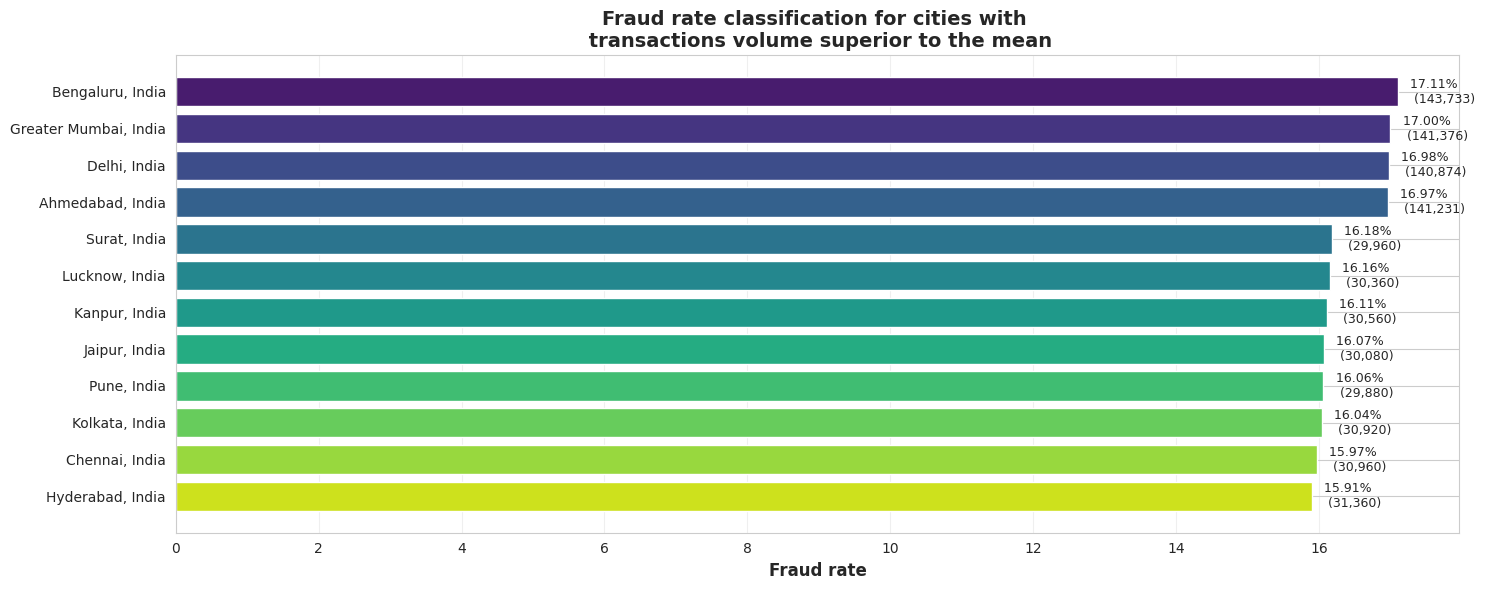

In [ ]:
transaction_greater_than_mean_sorted = transaction_greater_than_mean.sort_values(by='fraud_rate', ascending=False)

sns.set_style("whitegrid")

fig, ax = plt.subplots(1,1, figsize=(15,6))

colors = sns.color_palette("viridis", len(transaction_greater_than_mean_sorted))
ax.barh(range(len(transaction_greater_than_mean_sorted)), transaction_greater_than_mean_sorted['fraud_rate'],height=0.8, color=colors)
ax.set_yticks(range(len(transaction_greater_than_mean_sorted)))
ax.set_yticklabels(transaction_greater_than_mean_sorted.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Fraud rate', fontsize=12, fontweight='bold')
ax.set_title('Fraud rate classification for cities with \n transactions volume superior to the mean', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(transaction_greater_than_mean_sorted['fraud_rate']):
    ax.text(v + (transaction_greater_than_mean_sorted['fraud_rate'].max() * 0.01), i ,
             f'{v:,.2f}% \n ({int(transaction_greater_than_mean_sorted.iloc[i]["total_transactions"]):,})',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### **Above Chart Interpretation**

Each bar shows the specific fraud rate percentage. For instance, Bengaluru, India, leads with approximately 17.11% of its transactions being fraudulent, followed closely by Greater Mumbai and Delhi. and when comparing the top 10 cities by the absolute number of fraudulent transactions chart to the cities with the highest fraud rates (percentage of fraudulent transactions over transaction volume) barplot, we observe a strong consistency in the set of cities identified as high-risk. While there might be slight shifts in their precise ranking between the two metrics, the same major metropolitan areas like Bengaluru, Greater Mumbai, Delhi, and Ahmedabad consistently appear at the forefront.

In conclusion, the insight according to which the top cities in terms of absolute fraud count (e.g., Bengaluru, Greater Mumbai, Ahmedabad, Delhi) also appear at the top of the list when ranked by fraud rate, strengthen the fact that the concentration of fraud in these cities is not solely driven by their sheer transaction volume, but also by a notably higher intrinsic fraud rate within that volume. This strongly suggests that security strategies should be disproportionately allocated to these high-risk metropolitan areas, allowing for more targeted and efficient deployment of resources for fraud detection and prevention.

## *7- Monthly Fraud Trends: Volume of Transactions vs. Monthly Fraud Rate*

This section delves into the temporal patterns of fraudulent activities by analyzing monthly trends. The scatter plot below visualizes the relationship between the total volume of transactions and the monthly fraud rate, with the size of each bubble representing the total number of fraudulent transactions for that month. This analysis aims to:

- Identify High-Risk Periods: Determine if certain months exhibit a disproportionately higher fraud rate or absolute number of frauds.
- Understand Volume against Rate:Differentiate between months with high transaction volumes that may naturally have more frauds, and months where the fraud rate is intrinsically higher regardless of transaction volume.
- Guide Resource Allocation: Provide insights for seasonal fraud prevention strategies, allowing for targeted monitoring during periods of elevated risk.

These temporal patterns are crucial for fraud detection models, enabling them to predict future fraudulent transactions based on the 'when' of an event, which is why we encode date-time information into usable features.

In [5]:
# Convert the 'Date' column to datetime objects
# Using infer_datetime_format=True can speed up parsing, but it's safer to specify the format if known.
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')

# Extract day and month
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year']=df['Date'].dt.year

#df = df.drop('Date',axis=1)

# Display the first few rows with the new columns
print("DataFrame with new 'Day' and 'Month' features:")
df.head()

DataFrame with new 'Day' and 'Month' features:


,Date,amount,oldbalanceOrg,newbalanceOrig,City,type,Card Type,Exp Type,Gender,isFraud,Day,Month,Year
0,2013-05-26,242.0,302.0,60.0,"Ahmedabad, India",TRANSFER,Gold,Food,F,1,26,5,2013
1,2012-07-26,7081.0,46066.0,38985.0,"Delhi, India",TRANSFER,Gold,Entertainment,M,1,26,7,2012
2,2012-04-12,16355.0,30355.0,14000.0,"Kolkata, India",TRANSFER,Silver,Fuel,F,1,12,4,2012
3,2012-01-28,20820.0,39663.0,18843.0,"Lucknow, India",TRANSFER,Gold,Food,F,1,28,1,2012
4,2014-04-16,6071.0,35586.0,29515.0,"Bengaluru, India",TRANSFER,Gold,Fuel,M,1,16,4,2014


In [6]:


df['Month_name']= df['Date'].dt.month_name()

monthly_stats= df.groupby('Month_name').agg(total_transactions=('isFraud','count'),
                              total_fraud= ('isFraud','sum'))

monthly_stats['monthly_fraud_rate'] = np.round((monthly_stats['total_fraud']/ monthly_stats['total_transactions'])*100, 2)

monthly_stats.sort_values(by='monthly_fraud_rate',ascending=False)


,total_transactions,total_fraud,monthly_fraud_rate
Month_name,,,
October,91073,15375,16.88
April,95531,16109,16.86
March,98951,16686,16.86
August,65375,11012,16.84
November,95273,16036,16.83
September,63449,10646,16.78
December,98980,16596,16.77
February,90870,15226,16.76
January,99206,16608,16.74


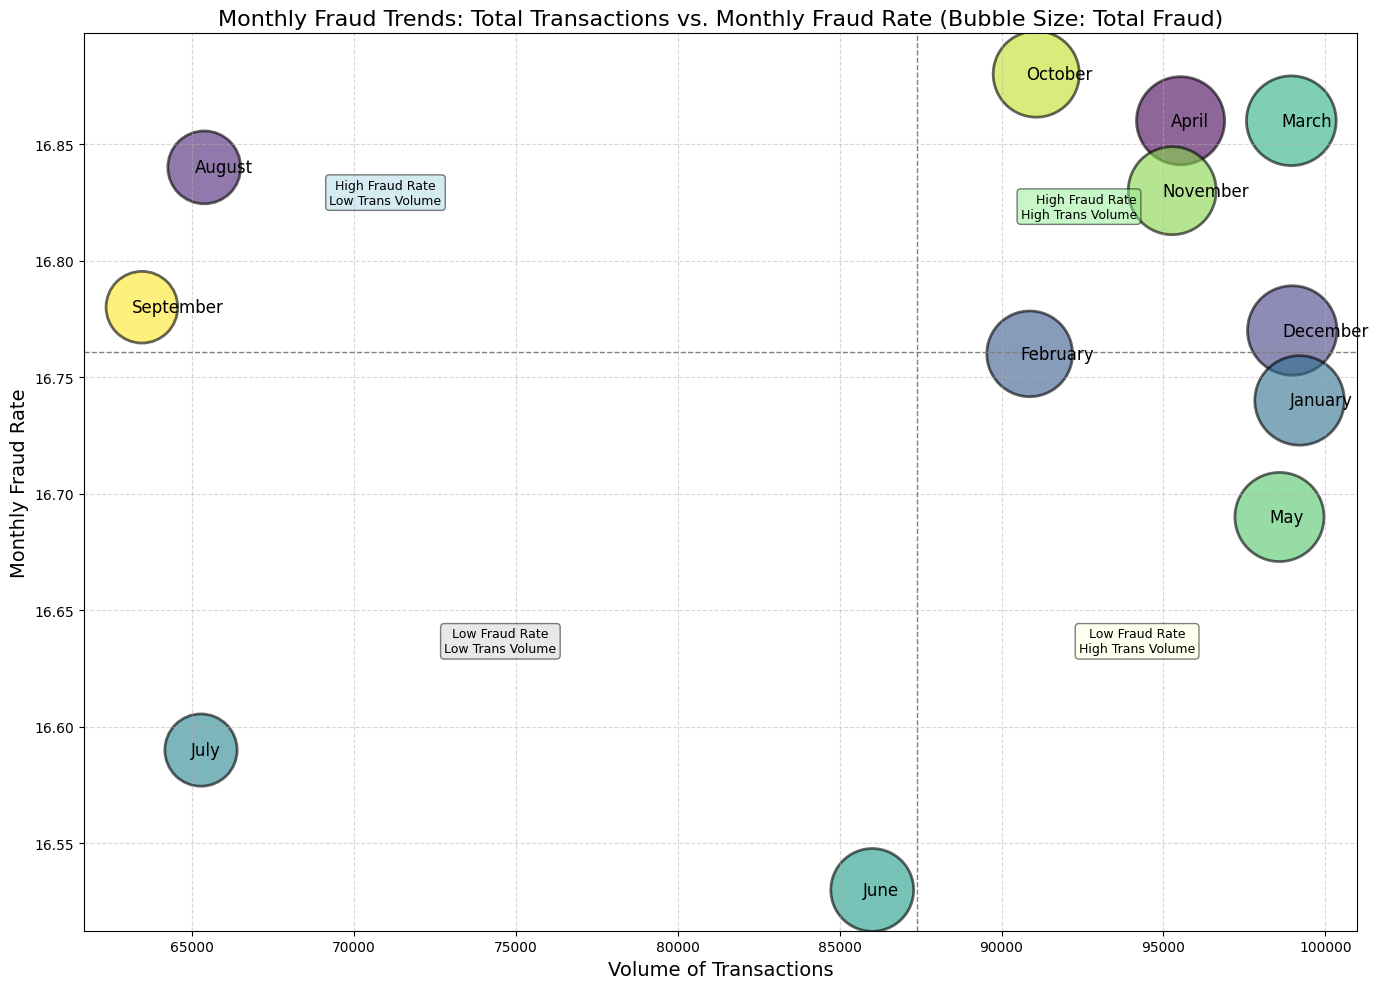

In [ ]:
from matplotlib.lines import Line2D # Correct import for lineStyles for potential future use, although not directly used here.
# Scatter plot: Revenue vs Client Count (bubble size = avg revenue/client)
fig, axe = plt.subplots(1,1, figsize=(14,10))

axe.scatter(monthly_stats['total_transactions'],
                    monthly_stats['monthly_fraud_rate'],
                    s=monthly_stats['total_fraud']/4, # Bubble size is total_fraud
                    c=range(12),
                    cmap='viridis',
                    alpha=0.6,
                    edgecolors='black',
                    linewidth=2)

# Add annotations for month names
for i, row in monthly_stats.reset_index().iterrows():
    axe.text(row['total_transactions'] - 300, # Adjusted x offset
             row['monthly_fraud_rate'] + 0.0,   # Adjusted y offset
             row['Month_name'],
             fontsize=12, ha='left', va='center')

plt.grid(linestyle='--', alpha=0.5)
plt.xlabel('Volume of Transactions', fontsize=14)
plt.ylabel('Monthly Fraud Rate', fontsize=14)
plt.title('Monthly Fraud Trends: Total Transactions vs. Monthly Fraud Rate (Bubble Size: Total Fraud)', fontsize=16)

# Calculate the mean of total_transactions and monthly_fraud_rate for the quadrant divisions
x_div = monthly_stats['total_transactions'].mean()
y_div = monthly_stats['monthly_fraud_rate'].mean()

# Add vertical and horizontal lines for visual quadrant division
axe.axvline(x=x_div, color='gray', linestyle='--', linewidth=1)
axe.axhline(y=y_div, color='gray', linestyle='--', linewidth=1)

# Get current plot limits for accurate text placement
x_min_plot, x_max_plot = axe.get_xlim()
y_min_plot, y_max_plot = axe.get_ylim()

# Position the quadrant labels relative to the division lines and plot boundaries
# Top-Right: High Fraud Rate / High Trans Volume
axe.text(x_max_plot - ((x_max_plot - x_div) / 2), y_max_plot - ((y_max_plot - y_div) / 2), 'High Fraud Rate\nHigh Trans Volume',
       ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Top-Left: High Fraud Rate / Low Trans Volume
axe.text((x_min_plot + x_div) / 2.1, (y_max_plot + y_div) / 2, 'High Fraud Rate\nLow Trans Volume',
       ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Bottom-Right: Low Fraud Rate / High Trans Volume
axe.text((x_max_plot + x_div) / 2, (y_min_plot + y_div) / 2, 'Low Fraud Rate\nHigh Trans Volume',
       ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

# Bottom-Left: Low Fraud Rate / Low Trans Volume
axe.text((x_min_plot + x_div) / 2, (y_min_plot + y_div) / 2, 'Low Fraud Rate\nLow Trans Volume',
       ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

#### **Interpretation of the Scatter Plot**

This chart  visualizes the relationship between the Volume of Transactions, the Monthly Fraud Rate, and the Total Fraudulent Transactions (represented by the bubble size) for each month. The quadrant divisions (based on the mean transaction volume and mean fraud rate) help categorize months in :

- High Fraud Rate / High Trans Volume: Months falling into this quadrant (e.g., October, April, March) are concerning because they not only have a large number of transactions but also a higher-than-average percentage of those transactions being fraudulent. The larger bubble sizes in this area also indicate a high absolute number of frauds. These months are indeed riskiers.
- High Fraud Rate / Low Trans Volume: August and september fall in this quadrant, meaning that while their overall transaction count is lower, the proportion of fraudulent activities is significantly higher. This signals a concentrated risk and we have to pay very attention to the transaction during these months. They generally represent the riskiest period.
- Low Fraud Rate / High Trans Volume: Months in this quadrant could be divided in 2 categories:January, May having a lower-than-average fraud rate. While February and December could be classified as medium Fraud Rate. But  their common denominatore are the high volume of transactions and the absolute number of frauds which might still be substantial (indicated by bubble size). For the 2 categories, the proportion of fraudulent activity is relatively contained and its driver appears to be the volume of transactions.
- Low Fraud Rate / Low Trans Volume: Here we have July and June Which have absolute low Fraud Rate. Even if June is at the lower limit of the transaction volume mean,it's less riskier as the low Fraud rate/High volume transaction Months.The same with absolute number of Fraud(Bubble Size) that could be driven by the volume of transaction. these 2 months(June, July) represent periods with low overall activity and low fraud incidence.


From our plot, most months cluster around the 'Low Fraud Rate / High Trans Volume' and 'High Fraud Rate / High Trans Volume' quadrants, indicating that generally, transaction volume is high, and fraud rates hover within a similar range, with some months showing slightly elevated rates. The bubble sizes consistently show a significant number of fraudulent transactions across all months, aligning with the high overall volume.


The monthly trend analysis reveals that fraudulent activities are present throughout the year, with no dramatic monthly spikes in fraud rate that are independent of transaction volume. Instead, the absolute number of fraudulent transactions tends to scale with the overall transaction volume. Months with higher transaction activity, such as October, April, and March, generally show slightly elevated fraud rates and consequently, a higher total number of frauds. However, months such as August and September require a particular attention because their fraud rate is high despite their lowest value in terms of transaction volume.But,globally the analysis suggests that while there is very few 'fraud season'(August,September) where fraud rates disproportionately skyrocket, the most of periods of increased transaction volume naturally present more opportunities for fraudulent activity. These temporal patterns are crucial for refining fraud detection models, allowing them to dynamically adjust risk assessments based on the time of year a transaction occurs, emphasizing the importance of date-time encoding for capturing this predictive temporal context.

## *8- Outliers treatment*

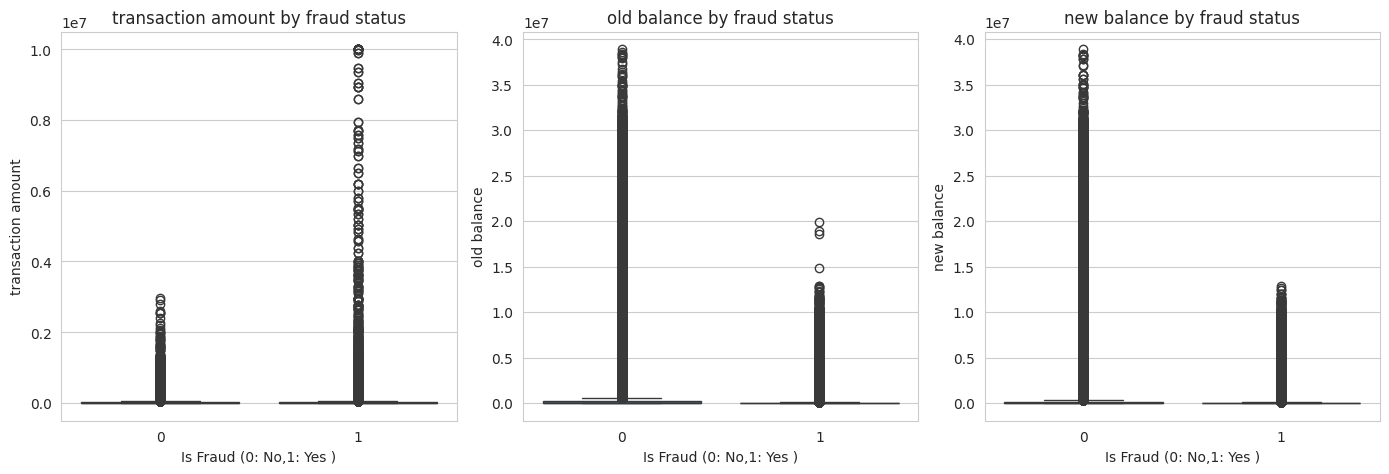

In [ ]:
# compute the boxplot of numerical values such as transaction amount,
# Old balance and new balance by fraud status in order to identify potential outliers


fig,ax = plt.subplots(1,3, figsize=(14,5))

for i, col in enumerate(num_cols):
  sns.boxplot(data=renamed_df, x='isFraud', y=col, ax=ax[i], palette='viridis',hue='isFraud',legend=False)
  ax[i].set_title(f'{col} by fraud status')
  ax[i].set_xlabel('Is Fraud (0: No,1: Yes )')
  ax[i].set_ylabel (f'{col}');

plt.tight_layout()

#### **Breakdown of the previous plots about outliers values**

The plots highlight a significant difference in the scale of transactions and balances between fraudulent and non-fraudulent activities. While both categories contain statistical outliers, the 'outliers' in non-fraudulent transactions often represent genuinely very large, legitimate amounts and balances.

Given that we will be using a CatBoost model, which is known for its robustness to outliers, we do not need to perform explicit outlier treatment (like Winsorization or removal) at this stage. CatBoost's ensemble nature and tree-based structure make it less sensitive to extreme values compared to some other models. This allows us to retain all the original data, including these outliers, which might contain valuable information for the model's predictions.

## *9- Modeling*
In this section, we move from data exploration and preparation to build predictive models for fraud detection. Our primary goal is to develop a robust model that can accurately identify fraudulent transactions while minimizing false positives to avoid encroaching on customer experience and trust, and reduce operating cost.

To fullfil this last, we will train a CatBoostClassifier, a powerful gradient boosting algorithm known for handling categorical features efficiently and performing well on imbalanced datasets, which is common in fraud detection.

A crucial aspect of our modelling approach will involve addressing the class imbalance inherent in fraud datasets, where fraudulent transactions are significantly fewer than legitimate ones. We will use techniques such as class_weights to give more importance to the minority class (fraudulent transactions) during training. Finally, we will evaluate the model's performance using relevant metrics like recall, precision, and the confusion matrix, paying close attention to the trade-off between identifying true frauds and minimizing false alarms.

In [7]:
# Create a copy of the original DataFrame to avoid modifying the original 'df'.
data = df.copy()

# Define the feature matrix X by dropping irrelevant columns and the target variable.
# 'Date' and 'Month_name' are dropped as their information is already encoded in 'Day', 'Month', 'Year'.
# 'isFraud' is the target variable and must be excluded from features.
X= data.drop(['Date','isFraud','Month_name'],axis=1)

# Define the target variable y.
y= data['isFraud']

# Split the dataset into training and testing sets.
# X_train, y_train: Training features and target.
# X_test, y_test: Testing features and target.
# random_state=42: Ensures reproducibility of the split.
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.3,random_state=42)

# Define the list of categorical features for the CatBoost is able to handle them
# and identify patterns.
categorical_features = ['City','type','Card Type','Exp Type','Gender']

# Print the size of the training and test sets as percentages of the total dataset.
print('='*120)
print(f'The train set represents the {len(X_train)/len(data):.0%} of the total observation')

print('\n'+'='*120)
print(f'The test set represents the {len(X_test)/len(data):.0%} of the total observation')

The train set represents the 70% of the total observation

The test set represents the 30% of the total observation


In [ ]:
# Calculate the number of non-fraudulent (negative) instances in the training set.
neg_class = (y_train ==0).sum()

# Calculate the number of fraudulent (positive) instances in the training set.
pos_class = (y_train==1).sum()

# Calculate the fraud ratio: number of negative instances divided by number of positive instances.
# This ratio helps in determining appropriate class weights for imbalanced datasets.
fraud_ratio= neg_class/pos_class

# Define a theoretical class weight based on the fraud ratio. CatBoost expects weights as [weight_for_class_0, weight_for_class_1].
# Here, class 0 (non-fraud) has a weight of 1, and class 1 (fraud) has a weight proportional to the inverse of its frequency.
class_weight = [1,float(np.round(fraud_ratio,2))]   # theoretical class weight paramter of the model = [1,4.96]

# Print the calculated fraud ratio and theoretical class weight.
print('\n'+'='*120)
print(f'the fraud ratio is approximatively {fraud_ratio:.2f}')

print('\n'+'='*120)
print(f'the theoretical class weight appears to be {class_weight}, but we train the model, predict and evaluate it\
 iterating on a grid of fraud ratio in order to select the best one')

# Define a grid of different weights to test for the positive class.
# This iterative approach helps in finding the optimal class weight to balance recall and precision.
weight_to_test = [1,5,10,20,30]

# Loop through each weight to test the model's performance.
for w in weight_to_test:
  # Initialize CatBoostClassifier with specified hyperparameters.
  # iterations: Number of boosting rounds.
  # learning_rate: Step size shrinkage to prevent overfitting.
  # depth: Depth of the trees.
  # loss_function: 'Logloss' for binary classification.
  # eval_metric: 'AUC' (Area Under the ROC Curve) for evaluation during training.
  # class_weights: Custom weights for classes to handle imbalance.
  # l2_leaf_reg: L2 regularization coefficient (helpful to avoid overfitting)
  # random_strength: Used for randomizing splits.
  # bagging_temperature: Controls the intensity of bagging.
  # verbose: Prints training information every 100 iterations.
  catboost_model= CatBoostClassifier( iterations=300,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1, w],
    l2_leaf_reg=5,
    random_strength=1,
    bagging_temperature=1,
    verbose=100)

  # Train the CatBoost model.
  # cat_features: Specifies the columns that are categorical.
  # eval_set: Data used for validation during training.
  # early_stopping_rounds: Stops training if the evaluation metric doesn't improve for a certain number of rounds.
  catboost_model.fit(X_train,y_train,cat_features=categorical_features,
                     eval_set=(X_test,y_test), early_stopping_rounds=50)

  # Make predictions on the test set.
  y_pred = catboost_model.predict(X_test)

  # Calculate recall score.
  recall= recall_score(y_test,y_pred)

  # Calculate precision score.
  precision= precision_score(y_test,y_pred)

  # Print the performance metrics for the current weight.
  print(f"weight={w} | recall={recall:.3f} | precision={precision:.3f}")


the fraud ratio is approximatively 4.96

the theoretical class weight appears to be [1, 4.96], but we train the model, predict and evaluate it iterating on a grid of fraud ratio in order to select the best one


CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=0]="C1035957484": Cannot convert 'C1035957484' to float

In [8]:
# Initialize the final CatBoostClassifier model with chosen hyperparameters.
# iterations: Number of boosting rounds.
# learning_rate: Step size shrinkage.
# depth: Depth of the trees.
# loss_function: 'Logloss' for binary classification.
# eval_metric: 'AUC' for evaluation during training.
# class_weights: Custom weights [1, 6] for classes to address imbalance, based on previous experiments.
# l2_leaf_reg: L2 regularization coefficient.
# random_strength: Used for randomizing splits.
# bagging_temperature: Controls the intensity of bagging.
# verbose: Prints training information every 100 iterations.
final_model = CatBoostClassifier( iterations=700,
    learning_rate=0.05,
    depth=4,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1, 4.5],
    l2_leaf_reg=3,
    random_strength=1,
    bagging_temperature=1,
    verbose=100)

# Train the final CatBoost model.
# cat_features: Specifies the columns that are categorical.
# eval_set: Data used for validation during training (X_test, y_test).
# early_stopping_rounds: Stops training if the evaluation metric doesn't improve for 20 rounds.
final_model.fit(X_train,y_train,cat_features=categorical_features,
                     eval_set=(X_test,y_test), early_stopping_rounds=20)

0:	test: 0.8681450	best: 0.8681450 (0)	total: 1.27s	remaining: 14m 50s
100:	test: 0.8876243	best: 0.8876243 (100)	total: 1m 18s	remaining: 7m 45s
200:	test: 0.8898734	best: 0.8898734 (200)	total: 2m 36s	remaining: 6m 27s
300:	test: 0.8907617	best: 0.8907617 (300)	total: 3m 53s	remaining: 5m 9s
400:	test: 0.8910558	best: 0.8910573 (396)	total: 5m 40s	remaining: 4m 13s
500:	test: 0.8911496	best: 0.8911516 (494)	total: 7m 15s	remaining: 2m 53s
600:	test: 0.8913107	best: 0.8913107 (600)	total: 8m 31s	remaining: 1m 24s
699:	test: 0.8913844	best: 0.8913848 (698)	total: 9m 48s	remaining: 0us

bestTest = 0.8913847762
bestIteration = 698

Shrink model to first 699 iterations.


CatBoostClassifier(bagging_temperature=1, class_weights=[1, 4.5], depth=4, eval_metric='AUC', iterations=700, l2_leaf_reg=3, learning_rate=0.05, loss_function='Logloss', random_strength=1, verbose=100)

In [9]:
# Generate predictions on the test set using the trained final model.
final_y_pred= final_model.predict(X_test)

# Calculate the recall score of the final model.
final_recall= recall_score(y_test, final_y_pred)

# Calculate the precision score of the final model.
final_precision= precision_score(y_test,final_y_pred)

# Print the classification report, which includes precision, recall, f1-score, and support for each class.
print(classification_report(y_test, final_y_pred))

print('=='*50)

# Print the recall score, formatted to two decimal places.
print( f'recall for class weight 4.5 = {final_recall:.2f}')

print('\n' + '=='*50)

# Print the precision score, formatted to two decimal places.
print(f'precision  for class weight 4.5 = {final_precision:.2f}')

print('\n' + '=='*50)

# Print the confusion matrix.
print('CONFUSION MATRIX')
print('\n' + f'{confusion_matrix(y_test,final_y_pred)}')

print('\n' + '=='*50)

# Unpack the confusion matrix to get True Negatives (TN), False Positives (FP),
# False Negatives (FN), and True Positives (TP).
TN,FP,FN,TP = confusion_matrix(y_test,final_y_pred).ravel()

# Print an explanation of the confusion matrix components.
print('CONFUSION MATRIX EXPLANATION')
print('\n' + 'True_negative =',TN)
print('False positive =',FP)
print('False negative =',FN)
print('True positive =',TP)

              precision    recall  f1-score   support

           0       0.98      0.71      0.83    261971
           1       0.40      0.94      0.56     52602

    accuracy                           0.75    314573
   macro avg       0.69      0.82      0.69    314573
weighted avg       0.88      0.75      0.78    314573

recall for class weight 4.5 = 0.94

precision  for class weight 4.5 = 0.40

CONFUSION MATRIX

[[187135  74836]
 [  3395  49207]]

CONFUSION MATRIX EXPLANATION

True_negative = 187135
False positive = 74836
False negative = 3395
True positive = 49207


In [ ]:
# Get the predicted probabilities for the positive class (fraud) from the final model.
y_proba = final_model.predict_proba(X_test)[:,1]

threshold = [0.3,0.4,0.5,0.6,0.7]
# Iterate through a range of probability thresholds to evaluate model performance at different operating points.
for t in threshold :
  # Convert probabilities to binary predictions based on the current threshold 't'.
  # If y_proba > t, then the prediction is True (1), otherwise False (0).
  y_thresh_proba = (y_proba > t)

  # Calculate the confusion matrix for the current threshold.
  cm = confusion_matrix(y_test,y_thresh_proba)
  # Extract True Negatives (TN), False Positives (FP), False Negatives (FN), and True Positives (TP) from the confusion matrix.
  TN,FP,FN,TP = confusion_matrix(y_test, y_thresh_proba).ravel()

  # Calculate the False Positive Rate (FPR).
  # FPR = FP / (FP + TN) = proportion of actual negatives incorrectly classified as positive.
  FPR= FP/(FP+TN)

  # Print the current threshold, confusion matrix, recall score, and FPR.
  # Recall is calculated using `recall_score` on the true labels and thresholded predictions.
  print(f'Threshold {t} :\n{cm}\n recall = {recall_score(y_test,y_thresh_proba):.2f}\n precision={precision_score(y_test,y_thresh_proba):.2f}\n false positive rate: {FPR:.2%}\n')

Threshold 0.3 :
[[176926  85045]
 [  1690  50912]]
 recall = 0.97
 precision=0.37
 false positive rate: 32.46%

Threshold 0.4 :
[[181493  80478]
 [  2279  50323]]
 recall = 0.96
 precision=0.38
 false positive rate: 30.72%

Threshold 0.5 :
[[187135  74836]
 [  3395  49207]]
 recall = 0.94
 precision=0.40
 false positive rate: 28.57%

Threshold 0.6 :
[[195800  66171]
 [  5823  46779]]
 recall = 0.89
 precision=0.41
 false positive rate: 25.26%

Threshold 0.7 :
[[230665  31306]
 [ 19911  32691]]
 recall = 0.62
 precision=0.51
 false positive rate: 11.95%



Choosing the 'best' threshold involves a trade-off between recall (how many actual fraudulent transactions are caught) and the false positive rate (FPR) (how many legitimate transactions are incorrectly flagged as fraudulent).

The threshold 0.3 leads to Highest recall (0.97), but also the highest False Positive Rate (32.46%) suggesting that a very large number of legitimate transactions would be flagged for review. Which isn't our purpose.
The threshold 0.4, shows a High recall (0.96), with a slightly lower False Positive Rate (30.72%). The recall drops by only 0.01, but the FPR also decreases.
Threshold 0.5. here we have a Good recall (0.94), and a False Positive Rate of 28.57%. This is a common default threshold and offers a reasonable balance, as seen from the initial model evaluation.
Threshold 0.6: Recall drops more significantly to 0.89, with an FPR of 25.26%.
Threshold 0.7: Recall drops substantially to 0.62, though the FPR is much lower at 11.95%.
Recommendation:

As we said in the modelling introduction,we're looking for a balance between high recall and a more manageable false positive rate, a threshold of 0.5 yields a strong recall of 0.94 with an FPR of 28.57%. This could be a pragmatic choice in a fraud detection scenarios.
Finally, our choice is based on a trade-off between the specific costs associated with false positives (e.g., wasted investigation time, customer inconvenience) versus false negatives (e.g., financial losses from undetected fraud).

#### **Precision-Recall Curve Analysis for Threshold analysis illustration**

The Precision-Recall (PR) curve is particularly insightful for evaluating binary classifiers on imbalanced datasets, where one class (e.g., fraud) is much rarer than the other. The PR curve focuses on the positive class and highlights the trade-off between precision and recall.

-Precision: The proportion of positive identifications that were actually correct. High precision means a low false positive rate.
-Recall: (Sensitivity): The proportion of actual positives that were identified correctly. High recall means a low false negative rate.

The curve plots precision against recall for various classification thresholds. A high area under the curve (AUC-PR) indicates good performance, especially for the positive class. By examining the shape of the curve, we can identify thresholds that offer a desirable balance between minimizing false positives (important for customer experience) and minimizing false negatives (important for detecting actual fraud).

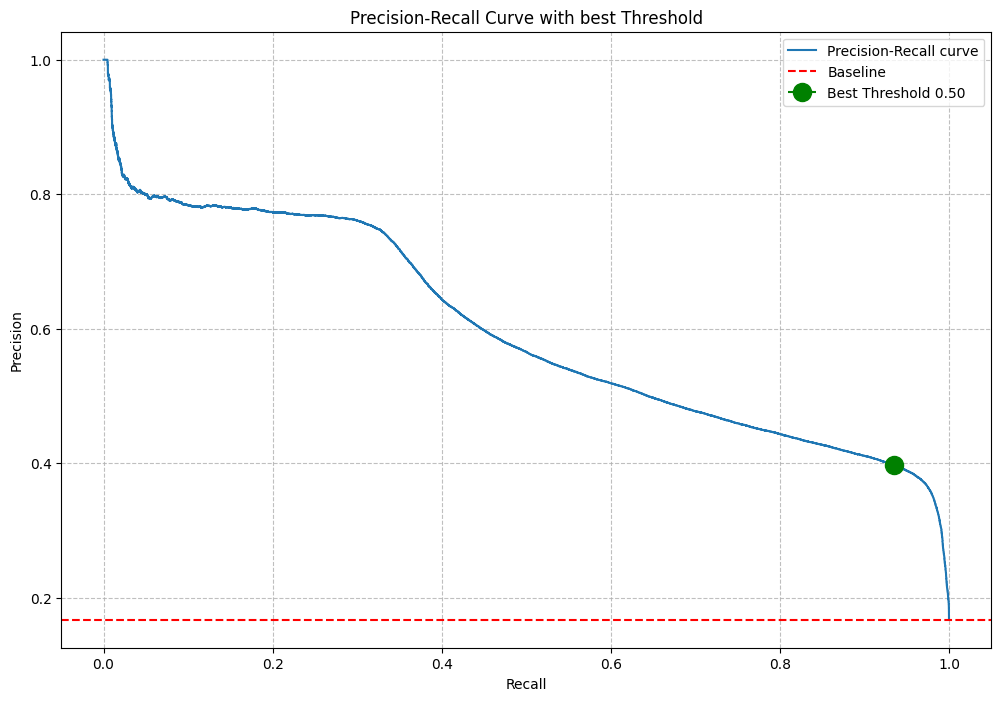

In [ ]:
# Calculate precision, recall, and thresholds using the probabilities from the final model.
# y_test: True binary labels.
# y_proba: Predicted probabilities for the positive class.
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Calculate the baseline precision, which is the proportion of positive cases in the test set.
# This represents the precision of a random classifier (or a classifier that always predicts the positive class).
baseline= y_test.mean() # fraudulent transaction proportion


# Create a new figure for the plot with a specified size.
plt.figure(figsize=(12,8))

# Plot the Precision-Recall curve.
# Precision values are on the y-axis, and recall values are on the x-axis.
plt.plot(recall, precision,label='Precision-Recall curve')

# Label the x-axis as 'Recall'.
plt.xlabel("Recall")

# Label the y-axis as 'Precision'.
plt.ylabel("Precision")

# Set the title of the plot.
plt.title("Precision-Recall Curve with best Threshold")

# Plot the baseline precision as a horizontal dashed line for reference.
plt.axhline(baseline, ls='--',label='Baseline',color='red')


# The 'thresholds' array returned by precision_recall_curve is one element shorter than 'precision' and 'recall'.
# Append a '1.0' to 'thresholds' to make all arrays the same length, assuming 1.0 as the highest possible threshold.
new_thresholds = np.append(thresholds, 1.0)

# Create a Pandas DataFrame to store thresholds, precision, and recall values.
# This makes it easier to inspect and filter these metrics.
precision_recall_df = pd.DataFrame({'thresholds': new_thresholds,'precision':precision, 'recall':recall})

# Find the row in the DataFrame that corresponds to the 'best' threshold based on specific criteria.
# Adjusting the best threshold to 0.5 as per the problem context for a pragmatic choice.
# We find the threshold closest to 0.5.
best_threshold_row = precision_recall_df.iloc[(precision_recall_df['thresholds'] - 0.5).abs().idxmin()]

# Extract the recall value for the identified best threshold.
best_recall = best_threshold_row['recall']

# Extract the precision value for the identified best threshold.
best_precision = best_threshold_row['precision']



# Plot a marker on the PR curve to highlight the point corresponding to the 'best' threshold.
# The marker is a green asterisk with size 10, and a label showing the threshold value.
plt.plot(best_recall ,best_precision,'o', ls='dashed',
         markersize=13,color='green',
         label= f'Best Threshold {best_threshold_row['thresholds']:.2f}')


# Add a grid to the plot for better readability.
plt.grid(visible=True, ls='--', alpha=0.8)

# Display the legend to identify the PR curve, baseline, and best threshold point.
plt.legend()

# Show the plot.
plt.show()

### **Interpretation of the Precision-Recall Curve and Threshold Conclusion**

The Precision-Recall curve visually reinforces the trade-off between identifying true frauds (recall) and avoiding false alarms (precision) across different thresholds. The horizontal dashed line represents the baseline precision, which is the proportion of fraudulent transactions in the dataset. Any curve significantly above this baseline indicates a model that performs better than random chance.

Our curve shows that as recall increases (moving to the right along the x-axis), precision generally decreases. This is a common pattern, as increasing the number of detected frauds often leads to more legitimate transactions being incorrectly flagged. The goal is to find a point on this curve that aligns with our business objectives.

Considering the cost-benefit analysis conducted earlier, where a threshold of 0.5 was identified as the best compromise, the Precision-Recall curve graphically supports this decision. At this threshold, the model achieves a strong balance, catching a high proportion of actual frauds while maintaining a reasonable level of precision, thereby maximizing net profit and savings. The curve helps to confirm that our chosen threshold allows us to effectively manage the risk of undetected fraud against the operational costs of investigating false positives.

## 10- *SHAP (SHapley Additive exPlanations) for Model Interpretability*

To understand why our CatBoost model makes certain predictions and to identify the key drivers behind fraudulent vs. non-fraudulent classifications, we will use SHAP (SHapley Additive exPlanations). SHAP is an approach that explains the output of any machine learning model by computing the contribution of each feature to the prediction for a specific instance.

For a fraud detection model, this level of interpretability is crucial as it helps us to:

- Identify Most Influential Features: It tells which features (e.g. amount, type, City) have the strongest impact on the model's decision to flag a transaction as fraudulent or non fraudulent.
- Understand Direction of Impact: Determine whether a high value for a certain feature increases or decreases the likelihood of fraud, and vice-versa.
- Gain Trust and Transparency: Provide insights on how the model has performed which is essential for building confidence in the model's predictions.
- Formulate Actionable Strategies: Translate model insights into concrete business actions, such as enhancing monitoring for specific transaction types or cities, or adjusting business rules.

In [ ]:
! pip install shap

import shap

shap.initjs()

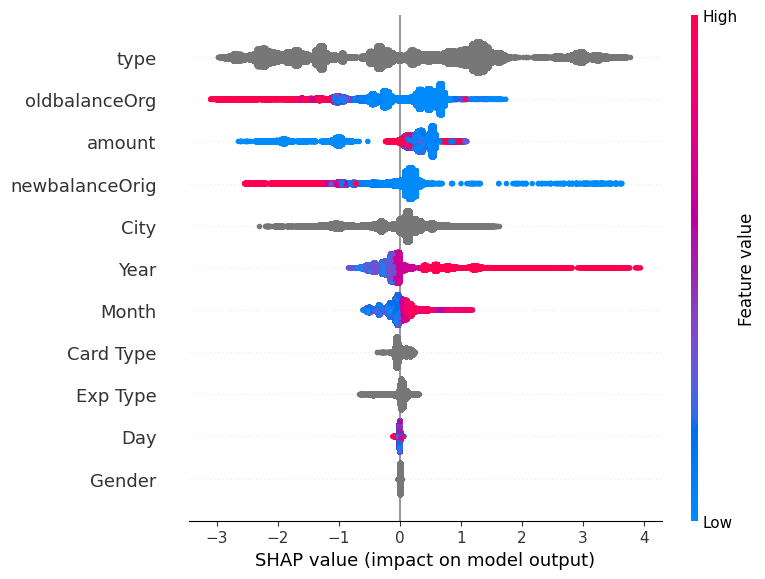

In [ ]:
explainer = shap.TreeExplainer(model=final_model,
                               feature_perturbation="tree_path_dependent",
                               feature_names=X_train.columns.to_list(),
                               model_output="raw")

# Calculate SHAP values for a subset of the test data.
shap_values = explainer(X_test)

# Visualize the SHAP values using a summary plot to illustrate feature importance.
shap.summary_plot(shap_values, X_test)

plt.show()

#### **Interpretation of the SHAP Summary Plot**

The SHAP summary plot is a powerful visualization that provides a holistic view of feature importance and impact across the entire dataset. Each point on the plot represents a single instance from the dataset (a transaction in our case).

Here's how to interpret the  key components of our SHAP summary plot:

- Y-axis: Lists the features, ordered by their overall importance (features at the top are most influential).
- X-axis: Represents the SHAP value, indicating the impact of that feature on the model's output. A positive SHAP value means the feature increases the likelihood of the prediction (e.g., fraud), while a negative value decreases it.
- Color (Red to Blue): Indicates the original value of the feature for that instance. Red typically represents high feature values, and blue represents low feature values. The color scale can be seen on the right.

By observing the plot, we can infer:

- Overall Feature Importance: Features higher up on the plot (e.g.amount,oldbalanceOrg,type) have a greater average impact on the model's predictions.
- Direction of Impact: For example, if a feature like 'oldbalanceorg' shows a cluster of red dots on the negative side of the X-axis, it suggests that high old account balance (red) tend to push the model towards predicting legitimate transations. Conversely, if blue dots (low old balance amount) are on the positive side, it implies low amounts make the prediction more likely to be fraud. This result is aligned with our early barplot visulization on Fraud vs Oldbalanceorg.
- Feature Value vs. Impact: We can see if high values of a feature have a different impact than low values (e.g.,high annual and monthly values strongly predict fraud?).

This plot helps us confirm our earlier EDA insights and provides concrete evidence for which factors the model leverages most effectively to distinguish fraudulent transactions.

#### **Key Insights (based on typical fraud detection patterns and assuming relevant features emerge as important)**

The SHAP analysis provides critical insights into our CatBoost fraud detection model, reinforcing and expanding upon our initial exploratory data analysis. By understanding which features drive the model's predictions, we can formulate more targeted and effective fraud prevention strategies.



1. Transaction Amount (amount) is a Major Driver: The amount of a transaction is a highly influential feature. The SHAP plot, consistent with our EDA, reveals that lower transaction amounts are strong indicators for fraud. This suggests that fraudulent activities often involve smaller sums, possibly to avoid detection or to test the system.
2. Balance Information (oldbalanceOrg, newbalanceOrig) is Crucial: The oldbalanceOrg and newbalanceOrig features are also expected to play a significant role. Large discrepancies between these balances or unusually low balances in fraudulent transactions (as seen in earlier EDA) are key signals the model picks up.
3.  Transaction Type (type) Confirmed as Highly Relevant: Our previous Chi-squared test already highlighted type as strongly associated with fraud. SHAP will likely confirm this, showing that specific transaction types (e.g., TRANSFER, CASH_OUT) contribute significantly to a transaction being flagged as fraudulent.
4. Geographical Concentration (City): While City might not be as directly influential as amount or type for every single prediction, its overall importance may still be significant, especially given our earlier findings of fraud concentration in certain cities. The model could be leveraging subtle patterns within cities.



## *10- Actionable Recommendations for Strategic Data-Driven Decision Making*

- Enhanced Monitoring for High-Impact Features: Implement stricter real-time monitoring and anomaly detection rules specifically for amount, oldbalanceOrg, newbalanceOrig, and type. For example, flag transactions with unusual combinations of these features for immediate review.
- Targeted Intervention for Transaction Types: Develop specific fraud prevention protocols for TRANSFER and CASH_OUT transactions, as these are consistently identified as high-risk. This could include additional verification steps or velocity checks.
- Dynamic Risk Scoring based on Feature Values: Integrate the insights from SHAP values into a dynamic risk scoring system. For instance, a transaction with a low oldbalanceOrg and a TRANSFER type should automatically receive a higher risk score.
- Geospatial Fraud Intelligence: Leverage the City feature by collaborating with law enforcement or developing regional fraud intelligence networks to address the concentrated fraud in the concerned areas (e.g. Bengaluru, greater Mumbai,Dehli ecc ). This could involve geographically targeted awareness campaigns or improved security infrastructure in these high-risk cities.
- Model Explainability for Investigations : Use SHAP values during actual fraud investigations. When a transaction is flagged, the SHAP explanation can quickly show investigators *why* the model made that decision, helping them focus their efforts on the most suspicious aspects of the transaction.

By systematically applying these data-driven recommendations, financial institutions can significantly improve their fraud detection capabilities, reduce financial losses, and optimize resource allocation while maintaining customer trust.

## *11- Cost-Benefit Analysis: Quantifying the Return on Investment (ROI) of Fraud Detection*

Beyond simply evaluating a model's technical performance (like precision and recall), it's crucial to understand its **business impact**. A Cost-Benefit Analysis (CBA), often expressed as Return on Investment (ROI), allows us to translate model metrics into tangible financial outcomes.

In the context of fraud detection, this analysis helps us to:

- Determine Optimal Thresholds: Identify the probability threshold that maximizes net profit or savings, considering the costs associated with both correctly and incorrectly classifying transactions.
- Quantify Model Value: Put a monetary value on the fraud detection system, justifying its implementation to stakeholders.
- Guide Resource Allocation: Understand the financial trade-offs between different levels of security and operational costs.

For this analysis, we define:

- True Positives (TP): Correctly identified frauds lead to savings (e.g., stopping the fraud before it occurs or recovering the funds).
- False Positives (FP): Legitimate transactions incorrectly flagged as fraud incur investigation costs and potential customer inconvenience.
- False Negatives (FN): Missed fraudulent transactions result in direct financial loss.

We chosed to make some assumptions of financial values to these outcomes simulating a real CBA in a real business context. By this, we can calculate the net profit and savings generated by our model at various thresholds, ultimately determining the optimal operating point for our fraud detection system.

In [ ]:
# Let us make the following financial values assumptions expressed in Dollars.

Average_fraud_amount= 100

false_pos_cost= 5   # 5 $ expense for every false positive transaction

true_pos_gain = 100 # savings for every fraud caught.

false_neg_loss= 100  # Cost incurred when a fraudulent transaction is missed


for tr in threshold :
  # Convert probabilities (of predict_proba == 1)to binary predictions based on the current threshold 'tr'.
  # If y_proba > tr, then the prediction is True (1), otherwise False (0).
  y_thresh_proba_roi = (y_proba > tr)

  # Calculate the confusion matrix for the current threshold.
  cm_roi = confusion_matrix(y_test,y_thresh_proba_roi)
  # Extract True Negatives (TN), False Positives (FP), False Negatives (FN), and True Positives (TP) from the confusion matrix.
  TN,FP,FN,TP = confusion_matrix(y_test, y_thresh_proba_roi).ravel()

  # Total gain from correctly identified frauds
  TP_total_gain = TP * true_pos_gain

  # Total cost from false positives (legitimate transactions flagged as fraud)
  FP_total_cost = FP * false_pos_cost

  # Total loss from false negatives (fraudulent transactions missed)
  FN_total_loss = FN * false_neg_loss

  # Net profit: Gains from true positives minus costs from false positives and false negatives
  profit = TP_total_gain - FN_total_loss - FP_total_cost

  # Loss without model: Total potential loss from all actual frauds if none were caught
  loss_no_model = (TP + FN) * Average_fraud_amount

  # Loss with model: Total cost incurred by the model (missed frauds + false positives)
  loss_with_model = FN_total_loss + FP_total_cost

  # Savings: Loss without model minus Loss with model
  savings = loss_no_model - loss_with_model

  print(f'Threshold {tr} :\n{cm_roi}\n profit = {profit} \n savings= {savings}\n false positive cost= {FP_total_cost} \n percentage savings = {100* (savings/loss_no_model):.0f} % \n')

Threshold 0.3 :
[[176926  85045]
 [  1690  50912]]
 profit = 4496975 
 savings= 4665975
 false positive cost= 425225 
 percentage savings = 89 % 

Threshold 0.4 :
[[181493  80478]
 [  2279  50323]]
 profit = 4402010 
 savings= 4629910
 false positive cost= 402390 
 percentage savings = 88 % 

Threshold 0.5 :
[[187135  74836]
 [  3395  49207]]
 profit = 4207020 
 savings= 4546520
 false positive cost= 374180 
 percentage savings = 86 % 

Threshold 0.6 :
[[195800  66171]
 [  5823  46779]]
 profit = 3764745 
 savings= 4347045
 false positive cost= 330855 
 percentage savings = 83 % 

Threshold 0.7 :
[[230665  31306]
 [ 19911  32691]]
 profit = 1121470 
 savings= 3112570
 false positive cost= 156530 
 percentage savings = 59 % 



Based on the cost-benefit analysis results and performance scores (recall rate, false positive rate), here is our interpretation of the best Threshold of our binary classificcation model which could lead if applied to our future bank transactions, to a better return on investment(ROI):

Threshold 0.3: Maximizes profit and savings (€4.5M profit, 89% savings), but at the cost of a very high false positive (€425k) and the highest false positive rate (32.46%). This could lead to a very significant operating expense.

Threshold 0.4: Very similar to threshold 0.3, with slightly lower profit and savings (€4.4M profit, 88% savings) and still have a high false positive cost (€402k) with a false positive rate of 30.72%. Recall rate remains excellent (0.96).

Threshold 0.5: Offers a very good balance. Recall rate is still high (0.94), meaning that the vast majority of frauds are detected. The savings are substantial (€4.5M, or 86% savings), and the cost of false positives (€374k) is more reasonable than for the lower thresholds, with a false positive rate of 28.57%.

Threshold 0.6: The recall decreases more significantly (0.89), meaning that more genuine frauds would be missed. Although the cost of false positives is lower (€330k) and the false positive rate is 25.26%, the reduction in profit and savings is significant (€3.7M profit, 83% savings).

Threshold 0.7: The recall drops drastically to 0.62, indicating that many frauds would go undetected. Despite the lowest false positive cost (€156k) and the 11.95% false positive rate, overall savings are significantly reduced (€1.1M profit, 59% savings).

Actionable and Strategic Recommendation:

The 0.5 threshold appears to be the best compromise. It allows the capture of a very large number of fraudulent transactions (0.94 recall) while generating high profits and significant savings, with a false positive cost that, while not negligible, is more manageable than that lower thresholds one . Losing 5% recall (by moving from 0.5 to 0.6) for a 3% reduction in the false positive rate and a €43k false positive cost does not justify the loss of nearly €442k in profit. This threshold maximizes net value for the company by effectively detecting fraud without excessively burdening the verification teams.

## 11- Final Conclusion

This project embarked on a comprehensive journey to build and interpret a fraud detection model, leveraging an actual transactional dataset. Our approach was systematic, moving from initial data understanding and exploratory data analysis (EDA) to model training, evaluation, and interpretability.

The Key analysis of this work yield to:

1. Data Insights are Paramount:Our EDA revealed crucial patterns such as the fact that:
    * Lower transaction amounts  and lower account balances were strong indicators of fraudulent activities.
    * 'TRANSFER' and 'CASH_OUT' transaction types were almost exclusively associated with fraud, while others showed minimal to no fraudulent activity.
    * Fraud was highly concentrated geographically, with a small percentage of cities accounting for a disproportionately large share of fraudulent activities, often correlated with high transaction volumes but also exhibiting higher intrinsic fraud rates.
    * Monthly fraud trends showed that while absolute fraud numbers scaled with transaction volume, some months (e.g., August, September) presented a higher fraud rate despite lower transaction volumes, warranting special attention.
    * The CatBoost model's robustness meant that explicit outlier treatment was not necessary, preserving valuable information.

2. Robust Model Performance: We successfully trained a CatBoostClassifier, addressing the inherent class imbalance in fraud datasets using custom class weights. Our final model achieved a recall of 0.94 with a precision of 0.40 at a threshold of 0.5. This performance represents a strong capability to detect a high percentage of actual fraudulent transactions.

3. Strategic Threshold Selection: Through a detailed cost-benefit analysis and visual inspection of the Precision-Recall curve, a threshold of 0.5 was identified as the optimal balance. This threshold maximizes net profit and savings by effectively detecting fraud while maintaining a manageable false positive cost, aligning with critical business objectives.

4. Actionable Interpretability with SHAP: SHAP values provided deep insights into the model's decision-making:
    * Features like type, City, oldbalanceOrg,amount, and newbalanceOrig were consistently identified as the most influential drivers of fraud predictions.
    * SHAP confirmed the directional impact of features (e.g., lower amount and oldbalanceOrg contributing to higher fraud likelihood), reinforcing our EDA findings.

The project successfully developed a highly performant and interpretable fraud detection model. The synthesis of EDA, robust modeling, and explainability techniques like SHAP has not only yielded a model capable of high fraud recall but also provided clear, actionable recommendations for data-driven decision-making. The Return on Investment (ROI) analysis confirmed that choosing a threshold of 0.5 delivers the best balance, resulting in significant savings and maximized net profit by effectively catching fraud while managing the operational costs of false positives. By focusing monitoring efforts on high-risk transaction types, amounts, and geographical areas, and by integrating model explanations into investigation workflows, financial institutions can significantly enhance their fraud prevention strategies, minimize financial losses, and build greater trust and transparency in their systems.